In [2]:
USE_SYNTHETIC = True          
DATA_PATH = "matches.csv" 
RANDOM_STATE = 42

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(RANDOM_STATE)

In [4]:
TEAMS = [
    "Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bangalore",
    "Kolkata Knight Riders", "Delhi Capitals", "Sunrisers Hyderabad",
    "Punjab Kings", "Rajasthan Royals", "Gujarat Titans", "Lucknow Super Giants"
]

VENUES = [
    "Wankhede Stadium", "M. Chinnaswamy Stadium", "Eden Gardens",
    "MA Chidambaram Stadium", "Arun Jaitley Stadium", "Narendra Modi Stadium",
    "Rajiv Gandhi Intl. Stadium", "Sawai Mansingh Stadium",
    "Punjab Cricket Association Stadium", "Ekana Cricket Stadium"
]

CITIES = {
    "Wankhede Stadium": "Mumbai", "M. Chinnaswamy Stadium": "Bangalore",
    "Eden Gardens": "Kolkata", "MA Chidambaram Stadium": "Chennai",
    "Arun Jaitley Stadium": "Delhi", "Narendra Modi Stadium": "Ahmedabad",
    "Rajiv Gandhi Intl. Stadium": "Hyderabad", "Sawai Mansingh Stadium": "Jaipur",
    "Punjab Cricket Association Stadium": "Mohali", "Ekana Cricket Stadium": "Lucknow"
}

def generate_synthetic_matches(n_matches=900, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    # give each team a hidden "strength" so outcomes aren't pure noise
    strength = {t: rng.normal(0, 1) for t in TEAMS}

    rows = []
    for i in range(n_matches):
        season = 2008 + (i % 17)
        team1, team2 = rng.choice(TEAMS, size=2, replace=False)
        venue = rng.choice(VENUES)
        toss_winner = rng.choice([team1, team2])
        toss_decision = rng.choice(["bat", "field"], p=[0.35, 0.65])

        # recent form: last-5-games win rate, simulated
        team1_form = np.clip(rng.normal(0.5 + strength[team1] * 0.05, 0.15), 0, 1)
        team2_form = np.clip(rng.normal(0.5 + strength[team2] * 0.05, 0.15), 0, 1)

        # head-to-head win % for team1 vs team2, simulated
        h2h_team1_win_pct = np.clip(rng.normal(0.5 + (strength[team1]-strength[team2])*0.05, 0.15), 0, 1)

        home_team = CITIES[venue]
        team1_home = 1 if home_team.lower() in team1.lower() else 0
        team2_home = 1 if home_team.lower() in team2.lower() else 0

        # win probability for team1 driven by strength, form, toss, home advantage
        score = (strength[team1] - strength[team2]) \
                + (team1_form - team2_form) * 1.5 \
                + (h2h_team1_win_pct - 0.5) * 1.2 \
                + (0.15 if toss_winner == team1 and toss_decision == "field" else 0) \
                + (0.2 if team1_home else 0) - (0.2 if team2_home else 0) \
                + rng.normal(0, 0.8)   # randomness / on-the-day variance

        prob_team1_wins = 1 / (1 + np.exp(-score))
        winner = team1 if rng.random() < prob_team1_wins else team2

        rows.append({
            "season": season,
            "team1": team1,
            "team2": team2,
            "venue": venue,
            "city": home_team,
            "toss_winner": toss_winner,
            "toss_decision": toss_decision,
            "team1_recent_form": round(team1_form, 3),
            "team2_recent_form": round(team2_form, 3),
            "h2h_team1_win_pct": round(h2h_team1_win_pct, 3),
            "team1_home": team1_home,
            "team2_home": team2_home,
            "winner": winner
        })
    return pd.DataFrame(rows)

if USE_SYNTHETIC:
    df = generate_synthetic_matches()
else:
    df = pd.read_csv(DATA_PATH)

df.head()

,season,team1,team2,venue,city,toss_winner,toss_decision,team1_recent_form,team2_recent_form,h2h_team1_win_pct,team1_home,team2_home,winner
0,2008,Kolkata Knight Riders,Delhi Capitals,Ekana Cricket Stadium,Lucknow,Delhi Capitals,field,0.617,0.274,0.700,0,0,Kolkata Knight Riders
1,2009,Sunrisers Hyderabad,Royal Challengers Bangalore,M. Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,0.618,0.514,0.333,0,1,Royal Challengers Bangalore
2,2010,Delhi Capitals,Mumbai Indians,M. Chinnaswamy Stadium,Bangalore,Mumbai Indians,field,0.341,0.438,0.265,0,0,Mumbai Indians
3,2011,Delhi Capitals,Punjab Kings,Rajiv Gandhi Intl. Stadium,Hyderabad,Delhi Capitals,bat,0.500,0.618,0.478,0,0,Punjab Kings
4,2012,Rajasthan Royals,Kolkata Knight Riders,Eden Gardens,Kolkata,Rajasthan Royals,bat,0.586,0.557,0.481,0,1,Kolkata Knight Riders


In [5]:
print(df.shape)
df.info()
df.isnull().sum()

(900, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season             900 non-null    int64  
 1   team1              900 non-null    object 
 2   team2              900 non-null    object 
 3   venue              900 non-null    object 
 4   city               900 non-null    object 
 5   toss_winner        900 non-null    object 
 6   toss_decision      900 non-null    object 
 7   team1_recent_form  900 non-null    float64
 8   team2_recent_form  900 non-null    float64
 9   h2h_team1_win_pct  900 non-null    float64
 10  team1_home         900 non-null    int64  
 11  team2_home         900 non-null    int64  
 12  winner             900 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 91.5+ KB


season               0
team1                0
team2                0
venue                0
city                 0
toss_winner          0
toss_decision        0
team1_recent_form    0
team2_recent_form    0
h2h_team1_win_pct    0
team1_home           0
team2_home           0
winner               0
dtype: int64

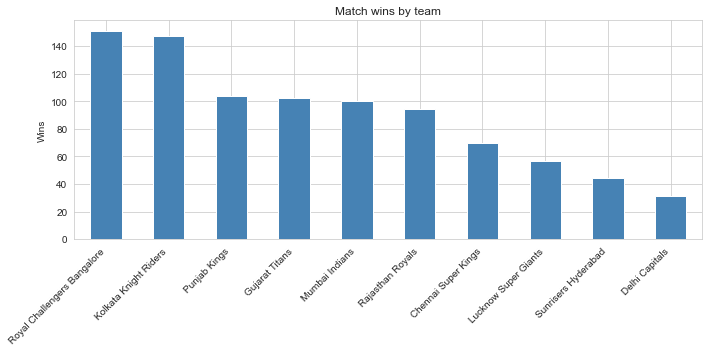

In [6]:
plt.figure(figsize=(10,5))
df["winner"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Match wins by team")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

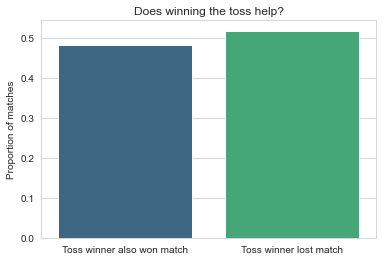

Toss winner also won the match in 48.2% of matches


In [7]:
plt.figure(figsize=(6,4))
toss_win_match = (df["toss_winner"] == df["winner"]).mean()
sns.barplot(x=["Toss winner also won match", "Toss winner lost match"],
            y=[toss_win_match, 1-toss_win_match], palette="viridis")
plt.ylabel("Proportion of matches")
plt.title("Does winning the toss help?")
plt.show()
print(f"Toss winner also won the match in {toss_win_match:.1%} of matches")

In [8]:
def add_form_and_h2h_features(matches, form_window=5):
    matches = matches.sort_values("season").reset_index(drop=True)
    team1_form, team2_form, h2h = [], [], []
    history = {t: [] for t in pd.unique(matches[["team1","team2"]].values.ravel())}
    h2h_record = {}

    for _, row in matches.iterrows():
        t1, t2, w = row["team1"], row["team2"], row["winner"]

        def recent_win_rate(team):
            games = history.get(team, [])[-form_window:]
            return np.mean(games) if games else 0.5

        team1_form.append(recent_win_rate(t1))
        team2_form.append(recent_win_rate(t2))

        key = tuple(sorted([t1, t2]))
        record = h2h_record.get(key, {"t1_wins": 0, "total": 0})
        h2h_t1_pct = (record["t1_wins"] / record["total"]) if record["total"] else 0.5
        # orient toward this row's team1
        h2h.append(h2h_t1_pct if key[0] == t1 else 1 - h2h_t1_pct)

        history.setdefault(t1, []).append(1 if w == t1 else 0)
        history.setdefault(t2, []).append(1 if w == t2 else 0)
        record["total"] += 1
        if w == key[0]:
            record["t1_wins"] += 1
        h2h_record[key] = record

    matches["team1_recent_form"] = team1_form
    matches["team2_recent_form"] = team2_form
    matches["h2h_team1_win_pct"] = h2h
    return matches

In [9]:
model_df = df.copy()

model_df["target"] = (model_df["winner"] == model_df["team1"]).astype(int)

categorical_cols = ["team1", "team2", "venue", "city", "toss_winner", "toss_decision"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col + "_enc"] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

model_df["toss_winner_is_team1"] = (model_df["toss_winner"] == model_df["team1"]).astype(int)

feature_cols = [
    "team1_enc", "team2_enc", "venue_enc", "city_enc",
    "toss_winner_enc", "toss_decision_enc", "toss_winner_is_team1",
    "team1_recent_form", "team2_recent_form", "h2h_team1_win_pct",
    "team1_home", "team2_home", "season"
]
# keep only columns that actually exist (in case some are missing from real data)
feature_cols = [c for c in feature_cols if c in model_df.columns]

X = model_df[feature_cols]
y = model_df["target"]

X.head()


,team1_enc,team2_enc,venue_enc,city_enc,toss_winner_enc,toss_decision_enc,toss_winner_is_team1,team1_recent_form,team2_recent_form,h2h_team1_win_pct,team1_home,team2_home,season
0,3,1,2,7,1,1,0,0.617,0.274,0.700,0,0,2008
1,9,8,3,1,8,1,0,0.618,0.514,0.333,0,1,2009
2,1,5,3,1,5,1,0,0.341,0.438,0.265,0,0,2010
3,1,6,7,4,1,0,1,0.500,0.618,0.478,0,0,2011
4,7,3,1,6,7,0,1,0.586,0.557,0.481,0,1,2012


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Class balance (train):", round(y_train.mean(), 3))


Train shape: (720, 13)  Test shape: (180, 13)
Class balance (train): 0.531


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()

    results.append({"Model": name, "Test Accuracy": acc, "5-Fold CV Accuracy": cv_acc, "ROC-AUC": auc})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Test Accuracy,5-Fold CV Accuracy,ROC-AUC
0,Gradient Boosting,0.716667,0.694444,0.764458
1,Random Forest,0.677778,0.680556,0.743653
2,Naive Bayes,0.672222,0.645833,0.700929
3,Logistic Regression,0.661111,0.651389,0.710464
4,Decision Tree,0.638889,0.608333,0.694799
5,SVM (RBF),0.633333,0.627778,0.658576
6,K-Nearest Neighbors,0.538889,0.593056,0.568111


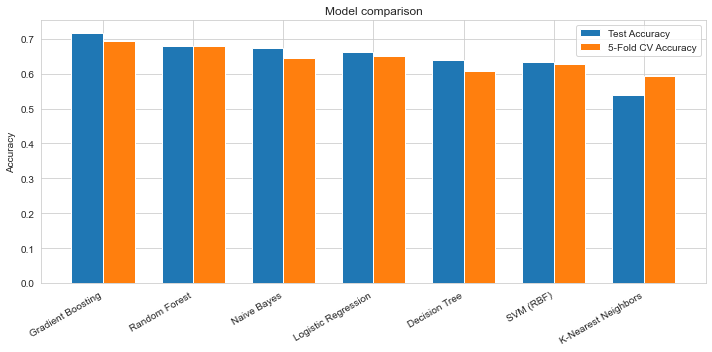

In [13]:
plt.figure(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
plt.bar(x - width/2, results_df["Test Accuracy"], width, label="Test Accuracy")
plt.bar(x + width/2, results_df["5-Fold CV Accuracy"], width, label="5-Fold CV Accuracy")
plt.xticks(x, results_df["Model"], rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Model comparison")
plt.legend()
plt.tight_layout()
plt.show()

Best model: Gradient Boosting
              precision    recall  f1-score   support

  team2 wins       0.69      0.73      0.71        85
  team1 wins       0.74      0.71      0.72        95

    accuracy                           0.72       180
   macro avg       0.72      0.72      0.72       180
weighted avg       0.72      0.72      0.72       180



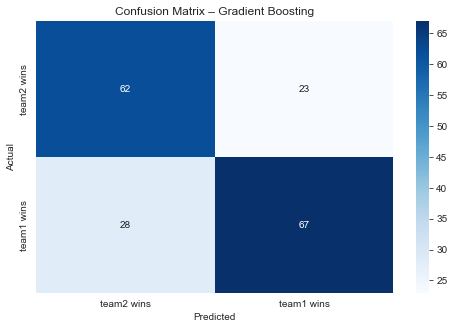

In [14]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

preds = best_model.predict(X_test_scaled)
print(classification_report(y_test, preds, target_names=["team2 wins", "team1 wins"]))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["team2 wins", "team1 wins"],
            yticklabels=["team2 wins", "team1 wins"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – {best_name}")
plt.show()


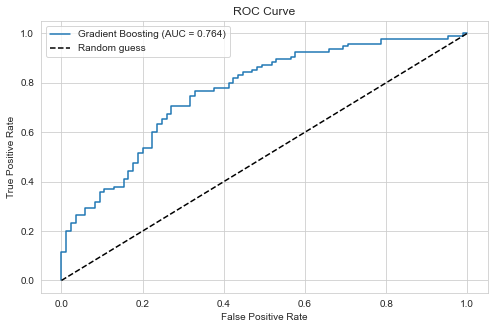

In [15]:
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{best_name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

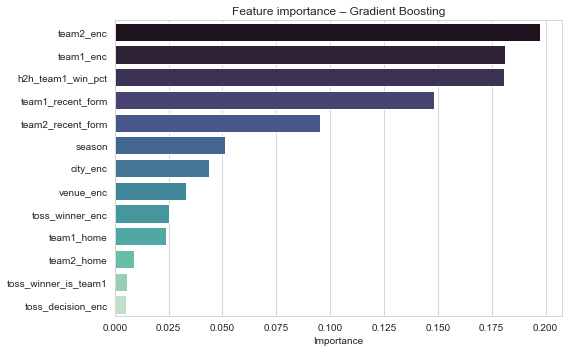

In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Feature importance – {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} doesn't expose feature_importances_ directly (e.g. it's a linear/kernel model).")

In [19]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV accuracy:", round(rf_grid.best_score_, 4))
print("Test accuracy with tuned model:", round(accuracy_score(y_test, rf_grid.predict(X_test_scaled)), 4))

Best params: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 300}
Best CV accuracy: 0.6917
Test accuracy with tuned model: 0.6889


In [18]:
def predict_match_winner(team1, team2, venue, toss_winner, toss_decision,
                          team1_recent_form=0.5, team2_recent_form=0.5,
                          h2h_team1_win_pct=0.5, season=2025, model=None):
    model = model or best_model
    city = CITIES.get(venue, "Unknown")

    def safe_encode(col, value):
        le = encoders[col]
        if value in le.classes_:
            return le.transform([value])[0]
        # unseen category fallback: encode as the most frequent class
        return le.transform([le.classes_[0]])[0]

    row = {
        "team1_enc": safe_encode("team1", team1),
        "team2_enc": safe_encode("team2", team2),
        "venue_enc": safe_encode("venue", venue),
        "city_enc": safe_encode("city", city),
        "toss_winner_enc": safe_encode("toss_winner", toss_winner),
        "toss_decision_enc": safe_encode("toss_decision", toss_decision),
        "toss_winner_is_team1": int(toss_winner == team1),
        "team1_recent_form": team1_recent_form,
        "team2_recent_form": team2_recent_form,
        "h2h_team1_win_pct": h2h_team1_win_pct,
        "team1_home": int(city.lower() in team1.lower()),
        "team2_home": int(city.lower() in team2.lower()),
        "season": season,
    }
    row = {k: row[k] for k in feature_cols}
    X_new = pd.DataFrame([row])
    X_new_scaled = scaler.transform(X_new)

    pred = model.predict(X_new_scaled)[0]
    proba = model.predict_proba(X_new_scaled)[0][1] if hasattr(model, "predict_proba") else None

    winner = team1 if pred == 1 else team2
    print(f"Predicted winner: {winner}")
    if proba is not None:
        print(f"P({team1} wins) = {proba:.1%}   |   P({team2} wins) = {1-proba:.1%}")
    return winner

# Example
predict_match_winner(
    team1="Mumbai Indians",
    team2="Chennai Super Kings",
    venue="Wankhede Stadium",
    toss_winner="Mumbai Indians",
    toss_decision="field",
    team1_recent_form=0.6,
    team2_recent_form=0.5,
    h2h_team1_win_pct=0.55,
)

Predicted winner: Mumbai Indians
P(Mumbai Indians wins) = 65.0%   |   P(Chennai Super Kings wins) = 35.0%


'Mumbai Indians'